<div align="center">
    <h1 style="font-size:48px;">Fine-Tuning Qwen3-4B with Unsloth & QLoRA</h1>
    <h3>An end-to-end guide to creating a custom LLM persona using synthetic data distillation</h3>
</div>
<hr>

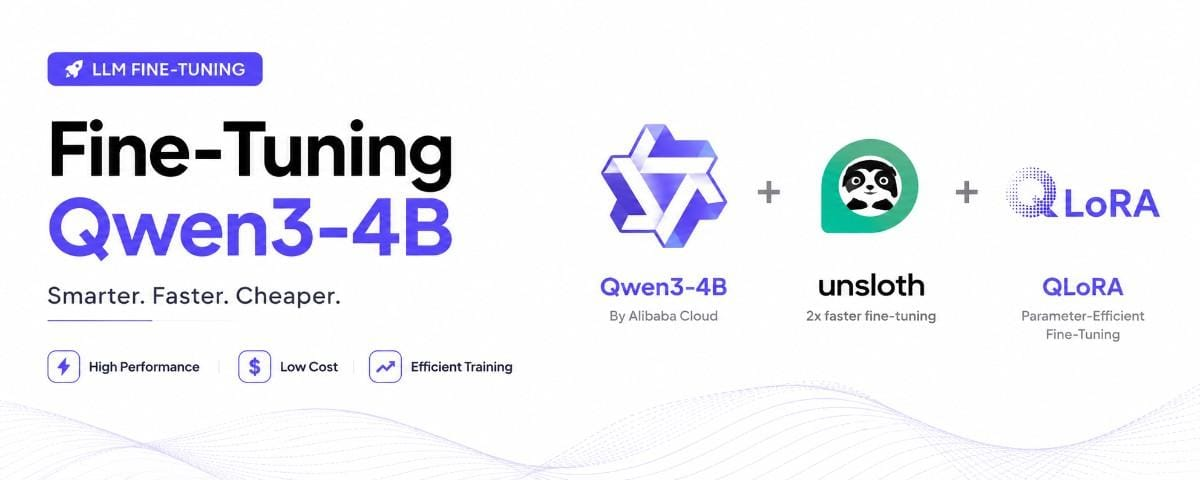

## **Install the Stack**

In [ ]:
%%capture
import os

!pip install pip3-autoremove
!pip install torch torchvision torchaudio xformers --index-url https://download.pytorch.org/whl/cu128
!pip install unsloth
!pip install --no-deps --upgrade "torchao>=0.16.0"
!pip install transformers==4.56.2
!pip install --no-deps trl==0.22.2
!pip install groq

## **Generate the Dataset with Groq**

In [ ]:
import asyncio, json, random
from groq import AsyncGroq
from kaggle_secrets import UserSecretsClient

client = AsyncGroq(api_key=UserSecretsClient().get_secret("GROQ_API_KEY"))

TOPICS = [
    "Python basics and data structures", "pandas and data cleaning",
    "machine learning fundamentals", "overfitting and regularization",
    "neural networks and backpropagation", "transformers and attention",
    "LLMs and how they are trained", "prompt engineering",
    "RAG and vector databases", "fine-tuning and LoRA",
    "AI agents and tool calling", "model evaluation and metrics",
    "APIs and deployment basics", "SQL and databases",
    "statistics for data science", "career advice for AI engineers",
]

SYSTEM_PROMPT = """You generate training data for 'ProTutor', an expert AI engineering tutor.
Each example is a question a beginner software developer would ask, plus ProTutor's answer.
Every answer MUST follow these 3 rules:
1. Written in clear, professional, and easy-to-understand standard English.
2. Explains the concept using a simple, universal real-world analogy (e.g., a library, a kitchen, a post office).
3. Ends with a clear one-line summary starting with 'Key Takeaway:'.
Keep answers 60-120 words. Vary question phrasing and difficulty.
Return JSON: {"examples": [{"user": "...", "assistant": "..."}, ...]}"""

async def generate_batch(topic: str, n: int = 20, retries: int = 3) -> list[dict]:
    """Ask the teacher model for n Q&A pairs about one topic. Backs off on rate limits."""
    for attempt in range(retries):
        try:
            resp = await client.chat.completions.create(
                model="openai/gpt-oss-120b",
                messages=[{"role": "system", "content": SYSTEM_PROMPT},
                          {"role": "user", "content": f"Generate {n} question-answer pairs about: {topic}"}],
                response_format={"type": "json_object"},
                temperature=0.9,
            )
            return json.loads(resp.choices[0].message.content)["examples"]
        except Exception as e:
            print(f" retry {attempt + 1} for '{topic}': {e}")
            await asyncio.sleep(20 * (attempt + 1))
    return []

async def build_dataset() -> list[dict]:
    """Generate all topics, 2 at a time - free tier allows 8,000 tokens/min, one call uses ~3,300."""
    pairs = []
    for i in range(0, len(TOPICS), 2):
        results = await asyncio.gather(*[generate_batch(t) for t in TOPICS[i:i + 2]])
        for batch in results:
            pairs.extend(batch)
        print(f"{len(pairs)} examples generated")
    return pairs

pairs = await build_dataset()
random.shuffle(pairs)

train_pairs, heldout_pairs = pairs[:-20], pairs[-20:]

with open("/kaggle/working/desitutor_data.json", "w") as f:
    json.dump({"train": train_pairs, "heldout": heldout_pairs}, f, ensure_ascii=False, indent=2)

print(f"Train: {len(train_pairs)}, Held-out: {len(heldout_pairs)}")
print(json.dumps(train_pairs[0], ensure_ascii=False, indent=2))

## **Load Qwen3-4B in 4-bit and Attach LoRA**
`Note:` from unsloth import FastLanguageModel must be the first import here.

In [ ]:
from unsloth import FastLanguageModel

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Qwen3-4B-Instruct-2507",
    max_seq_length = 2048,
    load_in_4bit = True,
    load_in_8bit = False,
    full_finetuning = False,
)

model = FastLanguageModel.get_peft_model(
    model,
    r = 32,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj", 
                      "gate_proj", "up_proj", "down_proj"],
    lora_alpha = 32,
    lora_dropout = 0,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
    random_state = 3407,
    use_rslora = False,
    loftq_config = None,
)

## **Format the Data with the Chat Template**

In [ ]:
from unsloth.chat_templates import get_chat_template
from datasets import Dataset

tokenizer = get_chat_template(tokenizer, chat_template = "qwen3-instruct")

def to_conversation(pair: dict) -> dict:
    """Wrap one Q&A pair in the role/content structure chat templates expect."""
    return {"conversations": [
        {"role": "user", "content": pair["user"]},
        {"role": "assistant", "content": pair["assistant"]},
    ]}

def formatting_prompts_func(examples: dict) -> dict:
    """Serialize each conversation into one ChatML training string."""
    texts = [tokenizer.apply_chat_template(c, tokenize = False, add_generation_prompt = False) 
             for c in examples["conversations"]]
    return {"text": texts}

dataset = Dataset.from_list([to_conversation(p) for p in train_pairs])
dataset = dataset.map(formatting_prompts_func, batched = True)
print(dataset[0]["text"])

## **Baseline: How the Base Model Talks**

In [ ]:
from transformers import TextStreamer

def ask(question: str, max_new_tokens: int = 200) -> str:
    """Generate one answer from the model in its current state."""
    messages = [{"role": "user", "content": question}]
    text = tokenizer.apply_chat_template(messages, tokenize = False, add_generation_prompt = True)
    inputs = tokenizer(text, return_tensors = "pt").to("cuda")
    out = model.generate(**inputs, max_new_tokens = max_new_tokens, 
                         temperature = 0.7, top_p = 0.8, top_k = 20)
    return tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens = True)

heldout_questions = [p["user"] for p in heldout_pairs]
base_answers = [ask(q) for q in heldout_questions]

print("Q:", heldout_questions[0])
print("BASE MODEL:", base_answers[0][:400])

## **Train**

In [ ]:
from trl import SFTTrainer, SFTConfig
from unsloth.chat_templates import train_on_responses_only

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset,
    eval_dataset = None,
    args = SFTConfig(
        dataset_text_field = "text",
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 5,
        max_steps = 60,
        learning_rate = 2e-4,
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.001,
        lr_scheduler_type = "linear",
        seed = 3407,
        report_to = "none",
    ),
)

trainer = train_on_responses_only(
    trainer,
    instruction_part = "<|im_start|>user\n",
    response_part = "<|im_start|>assistant\n",
)

stats = trainer.train()

## **Talk to Your Fine-Tuned Model**

In [ ]:
tuned_answers = [ask(q) for q in heldout_questions]

for q in [heldout_questions[0], "Why do we split data into train and test set"]:
    print(f"Q: {q}")
    print(f"TUNED MODEL: {ask(q)}\n")

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Create the UI components with professional styling layouts
title_html = widgets.HTML(
    value="<h2 style='margin-bottom: 5px;'>🤖 Chat with DesiTutor</h2>"
          "<p style='color: gray; margin-top: 0;'>Type an AI or Data Science question below to test your fine-tuned model.</p>"
)

text_input = widgets.Text(
    value='',
    placeholder='e.g., Explain Neural Networks like I am 5',
    description='Question:',
    layout=widgets.Layout(width='80%', max_width='600px', margin='10px 0')
)

submit_button = widgets.Button(
    description='Ask AiTutor',
    button_style='primary', # Gives it a professional accent color
    tooltip='Click to generate response',
    layout=widgets.Layout(margin='10px 0 10px 10px')
)

output_area = widgets.Output(
    layout=widgets.Layout(
        border='1px solid #ddd', 
        padding='15px', 
        margin='15px 0', 
        min_height='100px',
        max_width='680px',
        border_radius='4px'
    )
)

# Combine input bar and button on one horizontal row
input_box = widgets.HBox([text_input, submit_button], layout=widgets.Layout(align_items='center'))

# Define what happens when the button is clicked
def on_button_clicked(b):
    user_query = text_input.value.strip()
    if not user_query:
        return
        
    with output_area:
        clear_output()
        print("🤔 Thinking... Let me cook up a good analogy...")
        
        # Temporarily disable inputs while generating to prevent double clicks
        submit_button.disabled = True
        text_input.disabled = True
        
        try:
            # Calls the ask() function defined in Cell 5
            response = ask(user_query)
            clear_output()
            
            # Print the final tuned response
            print(response)
        except Exception as e:
            clear_output()
            print(f"❌ Error generating response: {e}")
            
        # Re-enable inputs
        submit_button.disabled = False
        text_input.disabled = False

# Bind the action to the button click and pressing Enter in the text field
submit_button.on_click(on_button_clicked)
text_input.on_submit(on_button_clicked)

# Render everything beautifully in the notebook
display(widgets.VBox([title_html, input_box, output_area]))